## Problem Statement
### In today’s highly competitive e-commerce environment, timely delivery plays a crucial role in customer satisfaction and business success. However, various factors such as high discounts, product weight, shipment mode, and customer-related attributes can cause delays in delivery.
### This project aims to develop a machine learning model that accurately predicts whether a product will be delivered on time or late — enabling companies to proactively manage logistics, reduce customer complaints, and enhance service reliability."

In [126]:
# Data Handling & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [128]:
df = pd.read_csv(r"C:\Users\SRISHTI\Downloads\OneDrive_2025-07-09\E-Commerce Product Delivery Prediction\E_Commerce.csv")

In [130]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [132]:
# Basic structure  

df.shape

(10999, 12)

In [134]:
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [138]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [140]:
# Null values 
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [142]:
# Duplicates
df.duplicated().sum()

0

## Univariate Analysis

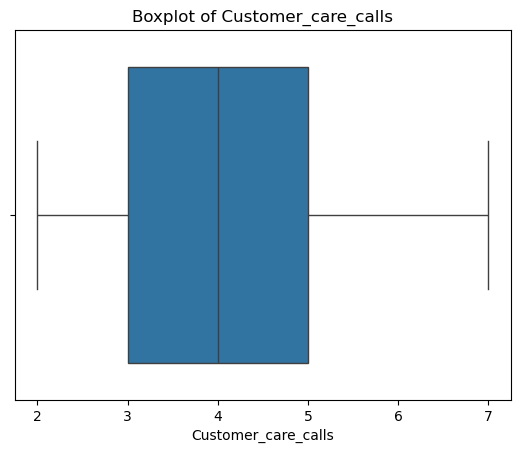

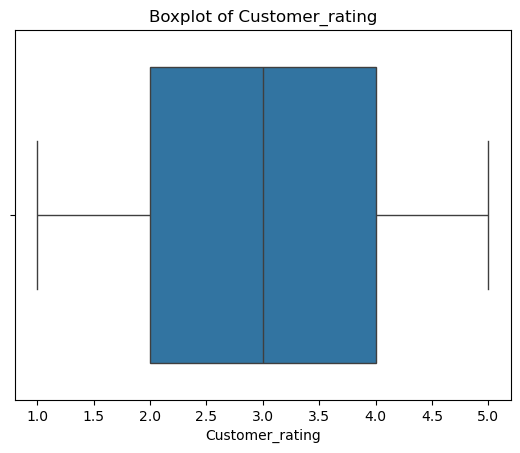

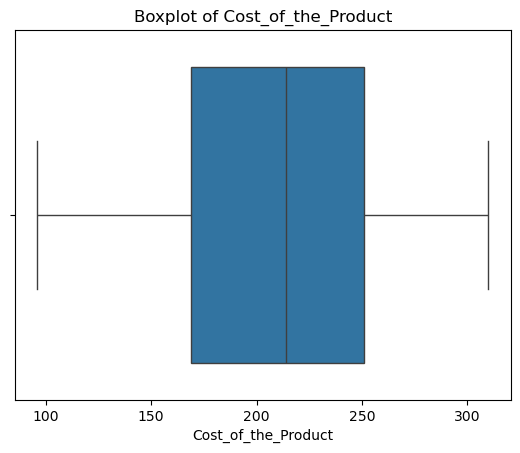

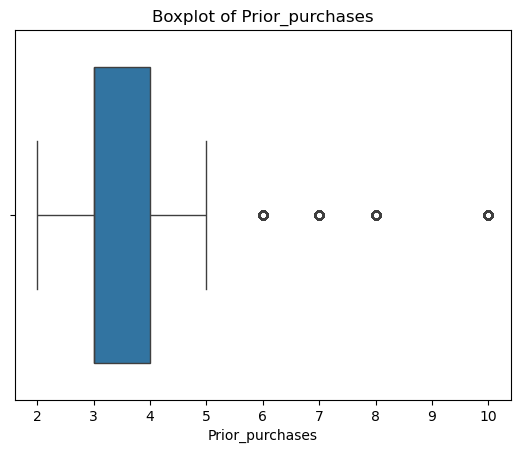

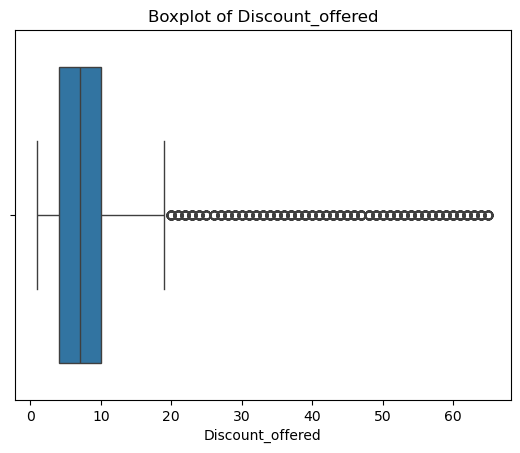

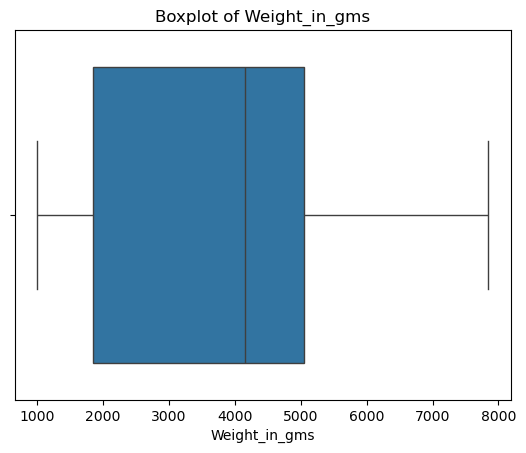

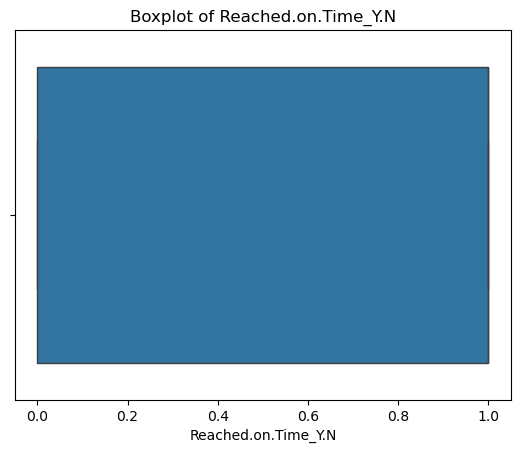

In [145]:
# Boxplot to check Outliers
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [146]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_limit, lower_limit,
               np.where(df[col] > upper_limit, upper_limit, df[col]))

cap_outliers('Prior_purchases')
cap_outliers('Discount_offered') 
cap_outliers('Weight_in_gms')

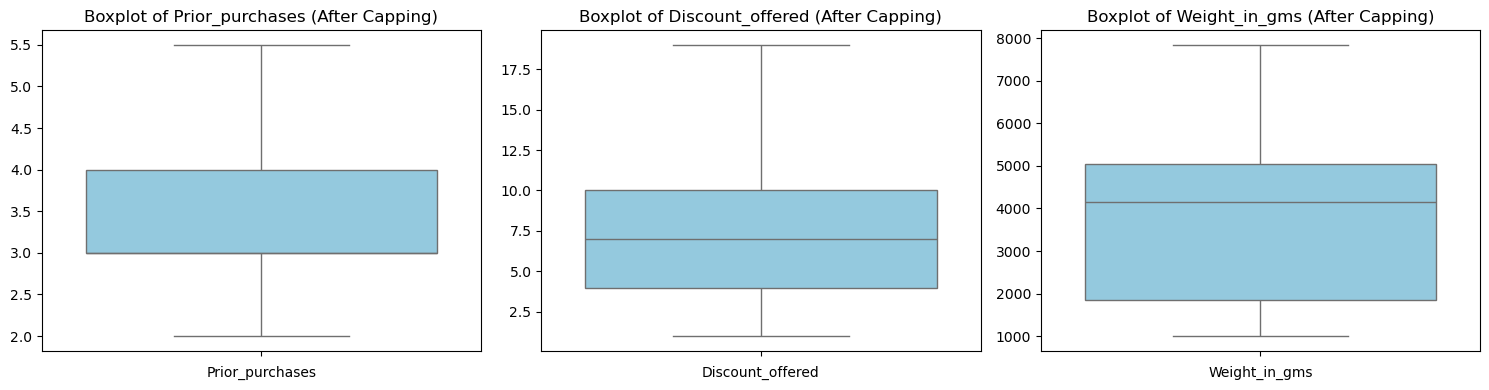

In [147]:
capped_columns = ['Prior_purchases', 'Discount_offered', 'Weight_in_gms']


# Plot boxplots
plt.figure(figsize=(15, 4))

for i, col in enumerate(capped_columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col} (After Capping)')
    plt.ylabel('')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

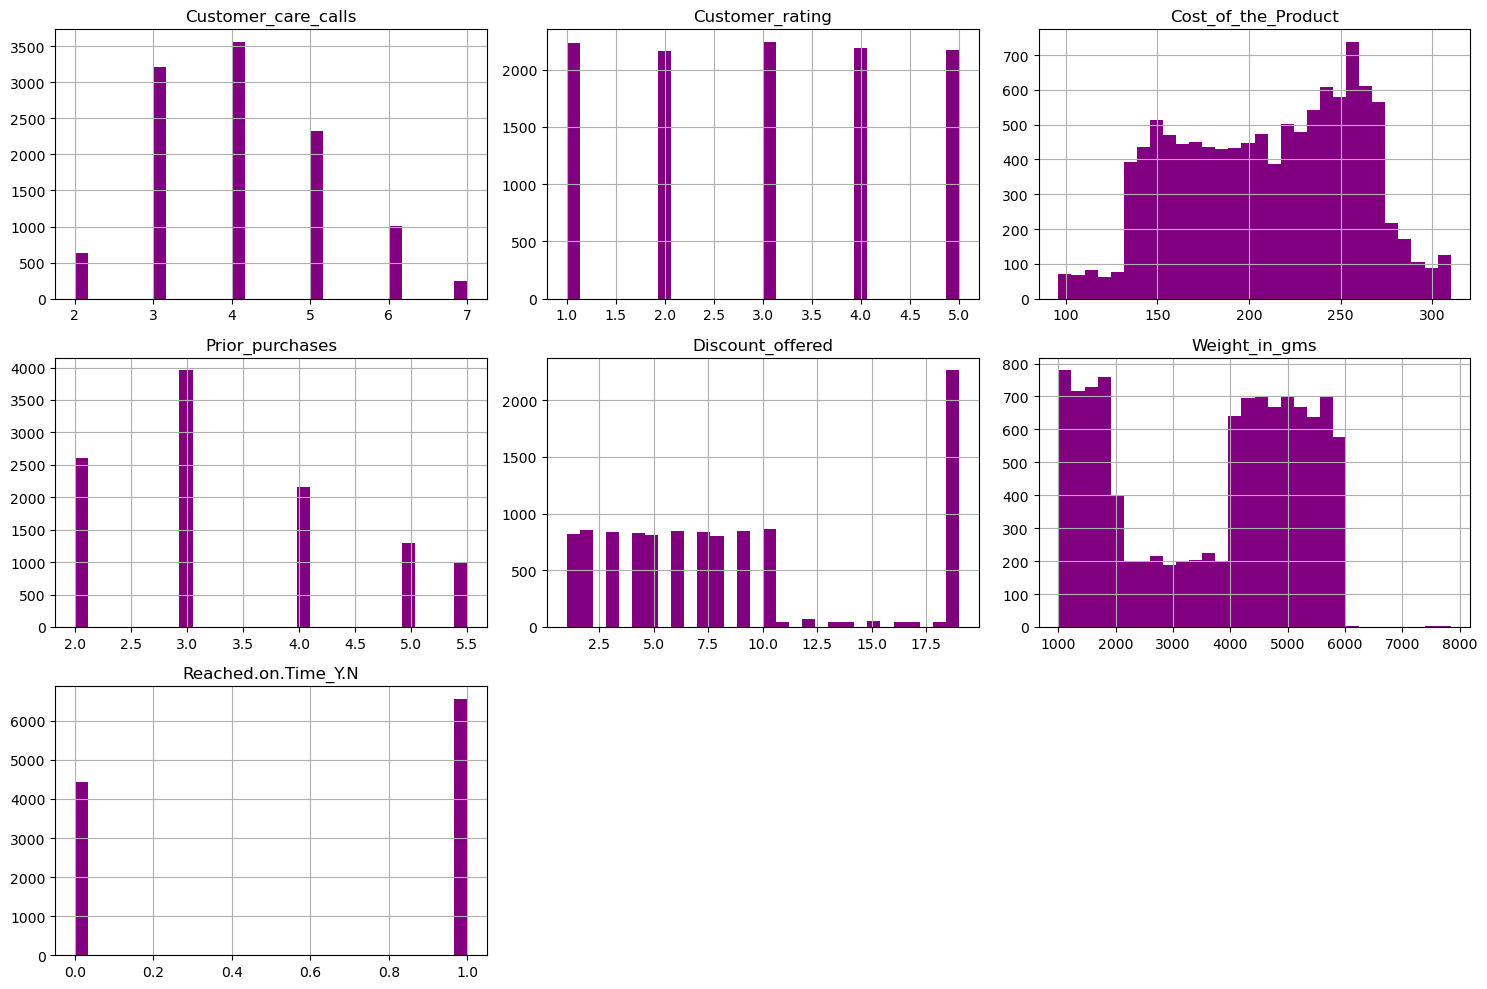

In [150]:
# Histogram for Numerical Features 

num_cols = ['Customer_care_calls' , 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
df[num_cols].hist(bins = 30, figsize =(15,10), color = 'purple')
plt.tight_layout()
plt.show()

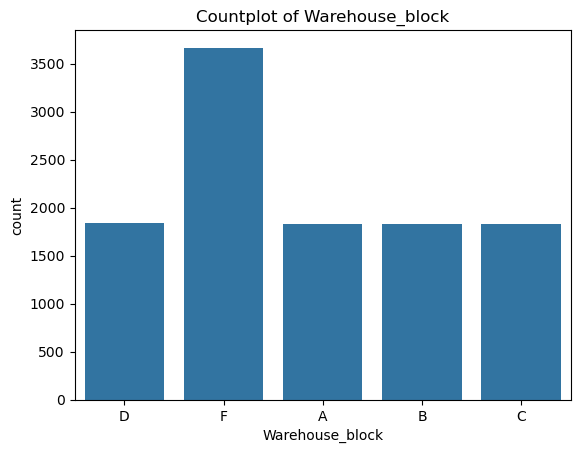

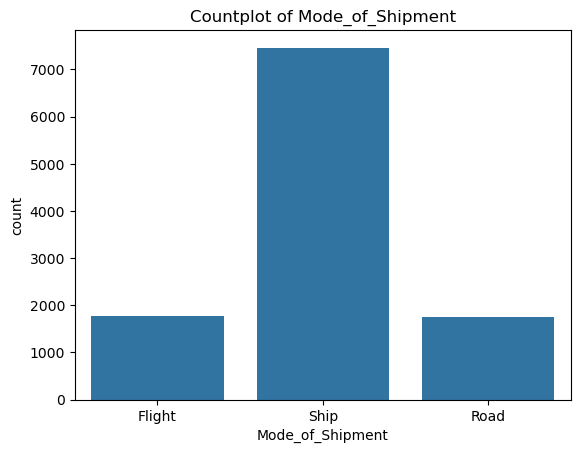

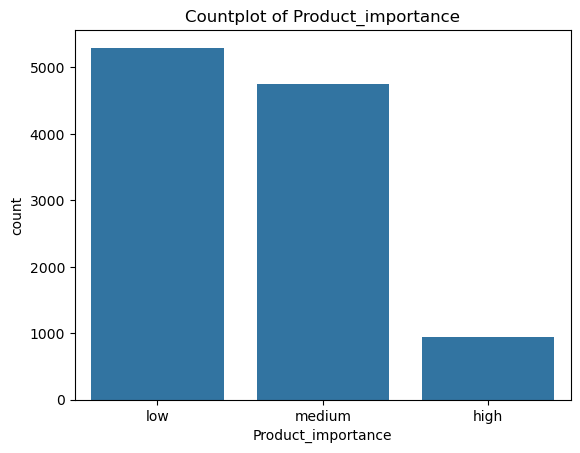

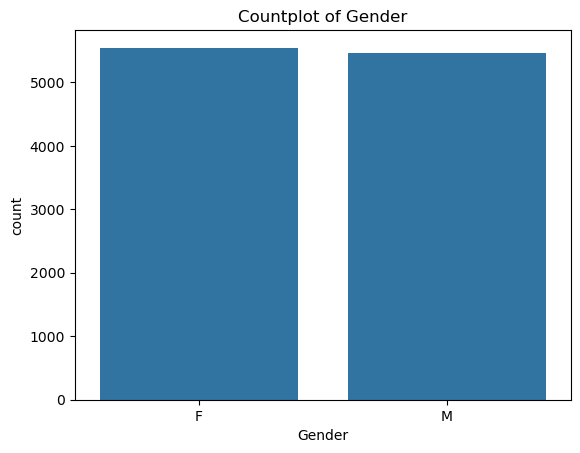

In [152]:
# Countplots for Categorical Features

cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.show()

## Bivariate Analysis ( Feature vs Traget )

Text(0.5, 1.0, 'Gender vs Reached on Time')

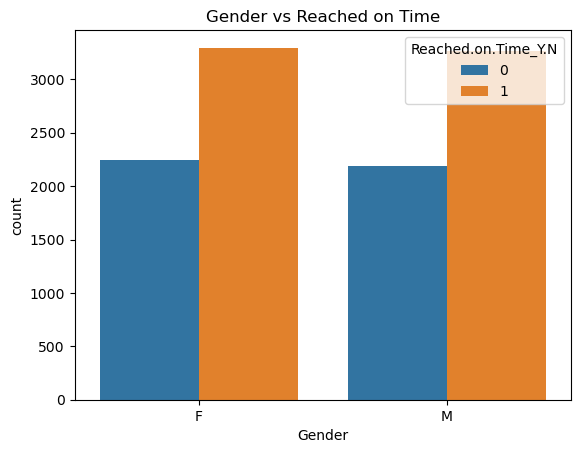

In [154]:
# Customer Gender and Product Delivery
sns.countplot(x = 'Gender', data = df, hue = 'Reached.on.Time_Y.N').set_title('Gender vs Reached on Time')

Text(0.5, 1.0, 'Cost of the Product')

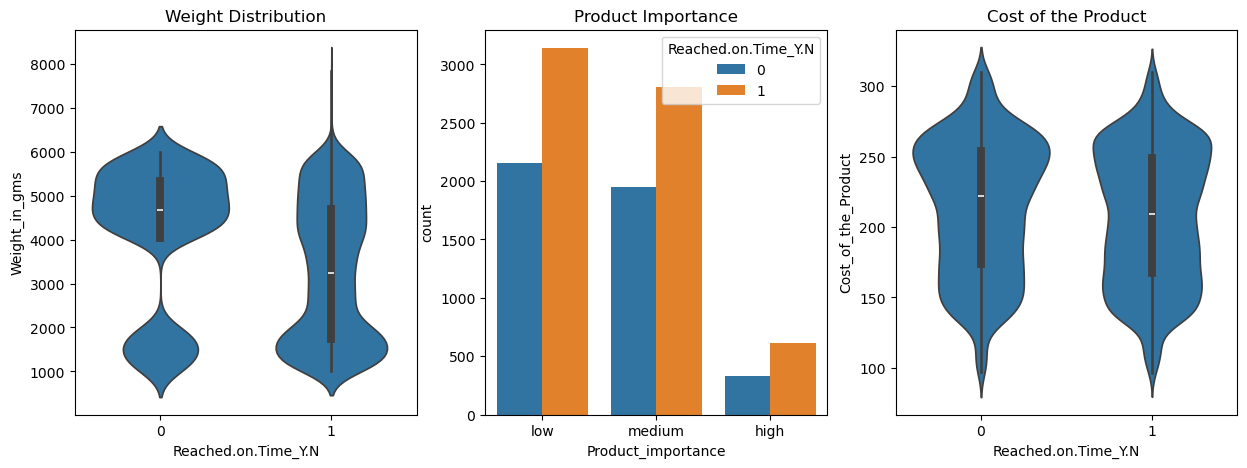

In [155]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
sns.violinplot(y = df['Weight_in_gms'], ax=ax[0], x = df['Reached.on.Time_Y.N']).set_title('Weight Distribution')
sns.countplot(x = 'Product_importance', data = df, ax=ax[1], hue = 'Reached.on.Time_Y.N').set_title('Product Importance')
sns.violinplot(y = df['Cost_of_the_Product'], ax=ax[2], x = df['Reached.on.Time_Y.N']).set_title('Cost of the Product') 
# The plots illustrate how product characteristics affect delivery timeliness. The first graph reveals that product weight influences delivery punctuality; specifically, products weighing over 4500 grams tend to be delivered late, whereas those in the 2500-3500 gram range are more often delivered on time. The second graph, focusing on product importance, indicates that this factor does not significantly affect delivery timeliness. The third graph shows a correlation between product cost and delivery, with products priced above $250 experiencing more frequent delivery delays.

# These observations suggest that both product weight and cost are significant factors affecting delivery timeliness.


Text(0.5, 1.0, 'Mode of Shipment')

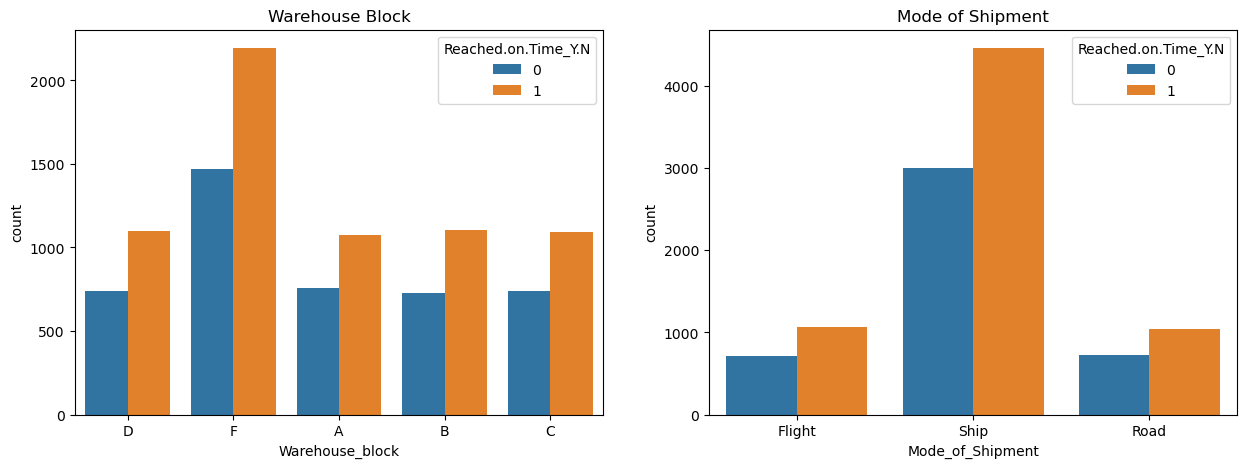

In [157]:
# Logistics and Product Delivery

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x = 'Warehouse_block', data = df, ax=ax[0], hue = 'Reached.on.Time_Y.N').set_title('Warehouse Block')
sns.countplot(x = 'Mode_of_Shipment', data = df, ax=ax[1], hue = 'Reached.on.Time_Y.N').set_title('Mode of Shipment')

# The graphs demonstrate the connection between logistics operations and the timely delivery of products. Given that the majority of products are dispatched from warehouse F, which is presumed to be near a seaport due to its high shipping volume, it's notable that the mode of shipment is predominantly by ship.

# However, the data shows a consistent difference in the number of products delivered on time versus late across all warehouses and shipping methods. This consistency suggests that the logistics, including the warehouse location and shipping method, do not significantly affect the timeliness of product delivery.

Text(0.5, 1.0, 'Discount Offered')

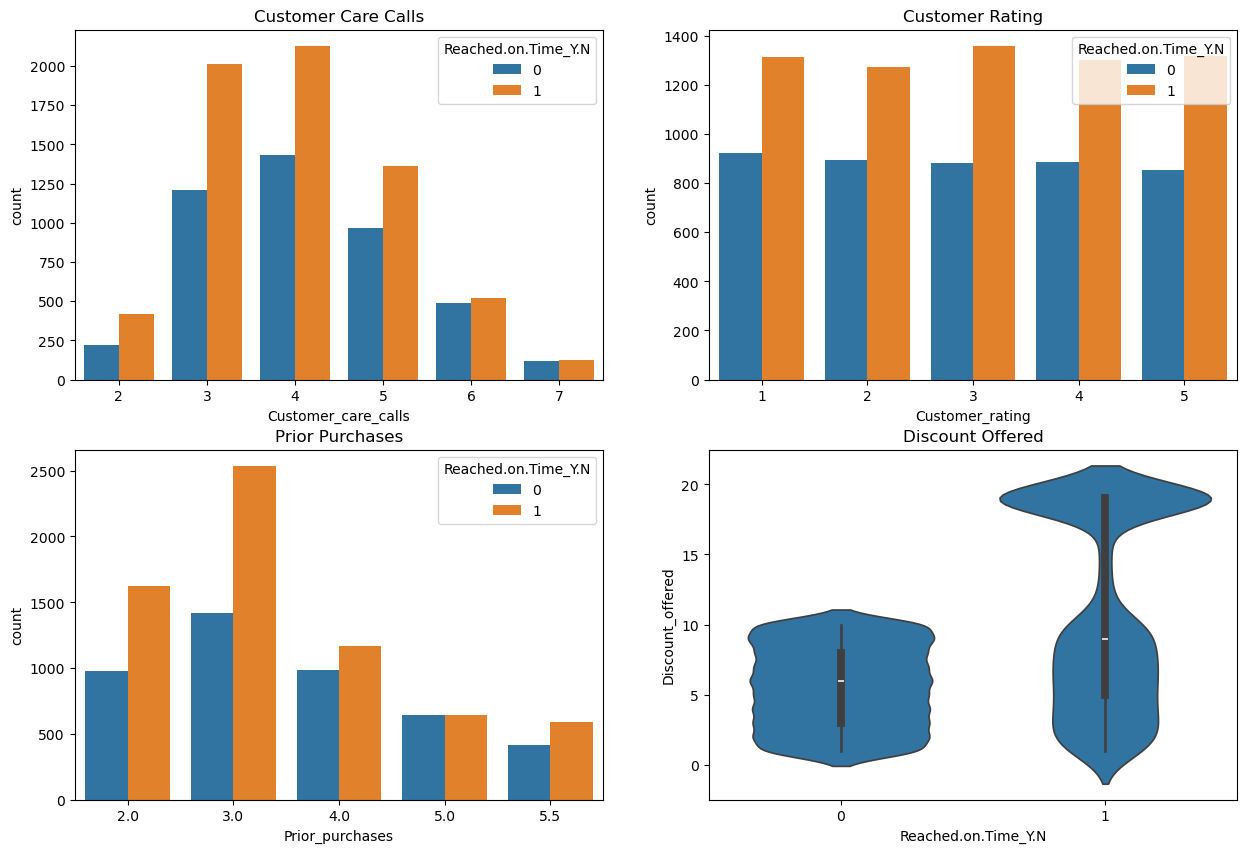

In [158]:
# Customer Experience and Product Delivery

fig, ax = plt.subplots(2,2,figsize=(15,10))
sns.countplot(x = 'Customer_care_calls', data = df, ax=ax[0,0],hue = 'Reached.on.Time_Y.N').set_title('Customer Care Calls')
sns.countplot(x = 'Customer_rating', data = df, ax=ax[0,1],hue = 'Reached.on.Time_Y.N').set_title('Customer Rating')
sns.countplot(x = 'Prior_purchases', data = df, ax=ax[1,0],hue = 'Reached.on.Time_Y.N').set_title('Prior Purchases')
sns.violinplot(x = 'Reached.on.Time_Y.N', y = 'Discount_offered' ,data = df, ax=ax[1,1]).set_title('Discount Offered')


# The graphs link customer experience with product delivery for an E-Commerce company. The first graph shows that as customer care calls increase, on-time deliveries decrease, suggesting customers call more when deliveries are late. The second graph indicates that customers with higher ratings often receive their products on time. The third graph reveals that customers who make repeat purchases tend to receive their products on time, likely encouraging their continued business. Lastly, the fourth graph shows that products with less than 10% discount are often delivered late, while those with more than 10% discount are delivered on time more frequently.

## Data Preprocessing

In [162]:
# If any column is not useful, we drop it:

df.drop('ID', axis = 1, inplace=True)

In [164]:
df.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3.0,low,F,19.0,1233.0,1
1,F,Flight,4,5,216,2.0,low,M,19.0,3088.0,1
2,A,Flight,2,2,183,4.0,low,M,19.0,3374.0,1
3,B,Flight,3,3,176,4.0,medium,M,10.0,1177.0,1
4,C,Flight,2,2,184,3.0,medium,F,19.0,2484.0,1


In [166]:
# Encode categorical features
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) 

In [167]:
df.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,4,2,177,3.0,19.0,1233.0,1,False,False,True,False,False,False,True,False,False
1,4,5,216,2.0,19.0,3088.0,1,False,False,False,True,False,False,True,False,True
2,2,2,183,4.0,19.0,3374.0,1,False,False,False,False,False,False,True,False,True
3,3,3,176,4.0,10.0,1177.0,1,True,False,False,False,False,False,False,True,True
4,2,2,184,3.0,19.0,2484.0,1,False,True,False,False,False,False,False,True,False


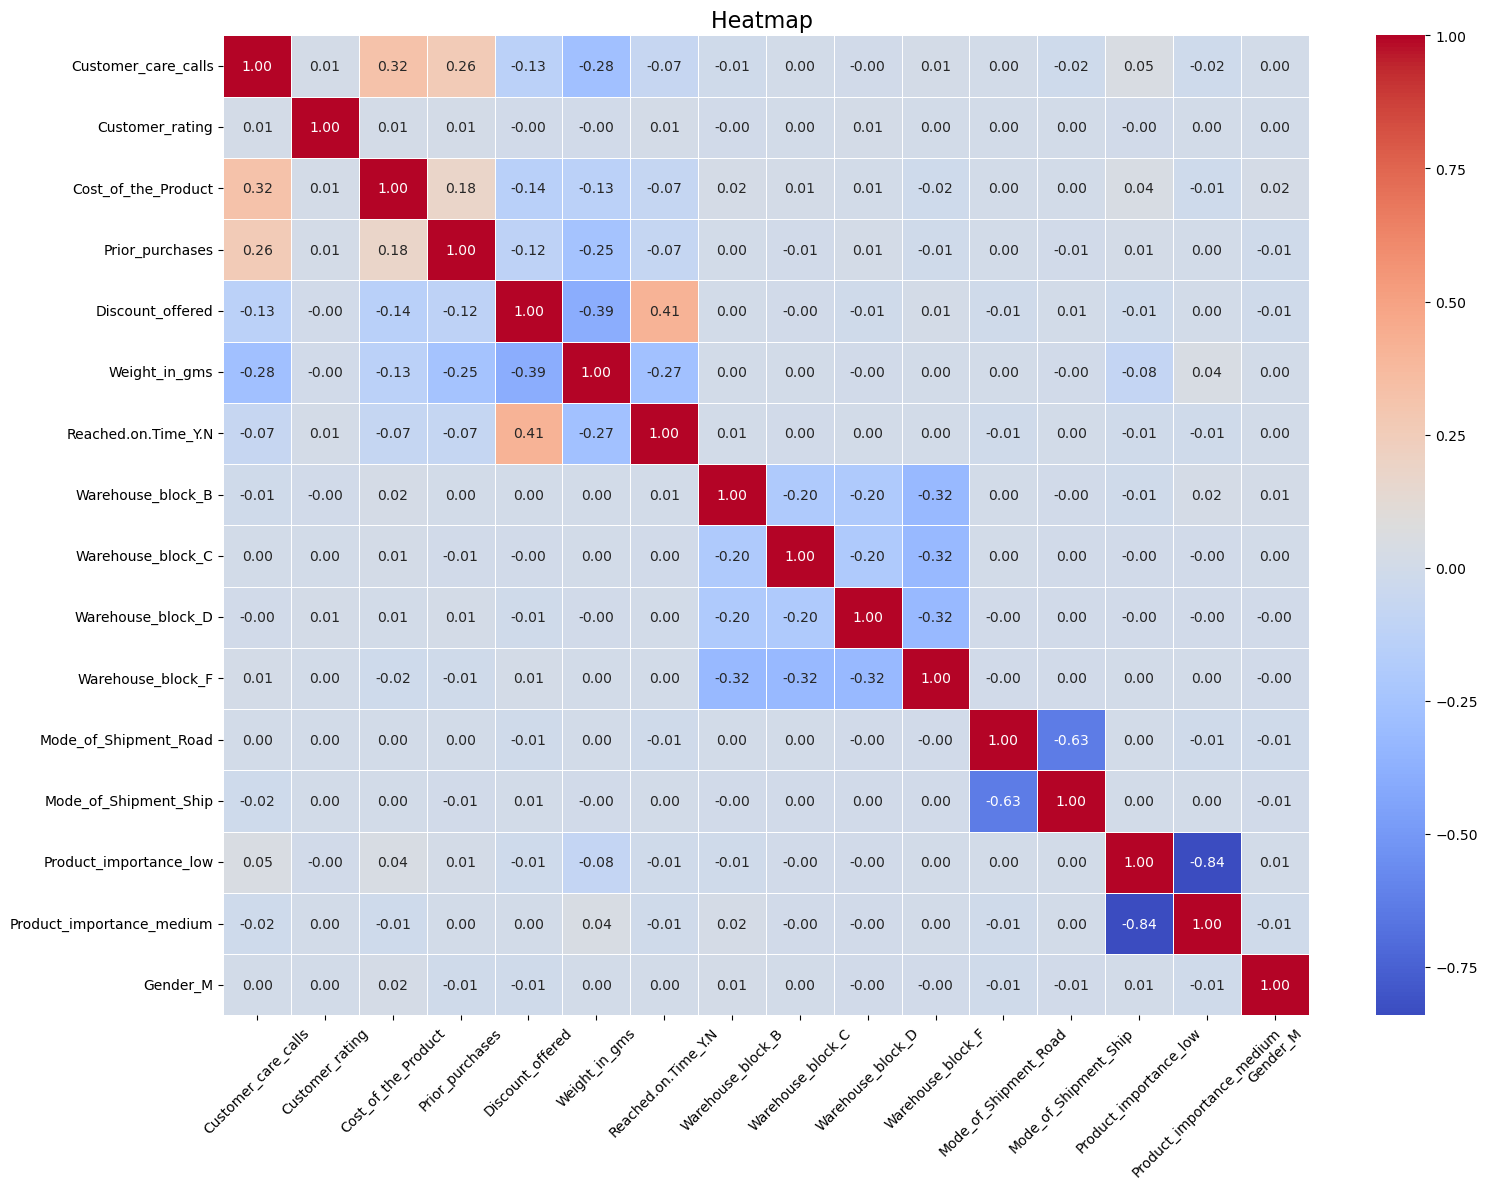

In [170]:
corr_matrix = df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Heatmap ", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [174]:
# Feature Scaling (Normalization)
scaler = StandardScaler()
num_features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product','Prior_purchases', 'Discount_offered', 'Weight_in_gms']

df[num_features] = scaler.fit_transform(df[num_features])

In [177]:
df.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,-0.047711,-0.700755,-0.690722,-0.370875,1.707748,-1.468240,1,False,False,True,False,False,False,True,False,False
1,-0.047711,1.421578,0.120746,-1.250497,1.707748,-0.333893,1,False,False,False,True,False,False,True,False,True
2,-1.799887,-0.700755,-0.565881,0.508748,1.707748,-0.159002,1,False,False,False,False,False,False,True,False,True
3,-0.923799,0.006689,-0.711529,0.508748,0.231172,-1.502484,1,True,False,False,False,False,False,False,True,True
4,-1.799887,-0.700755,-0.545074,-0.370875,1.707748,-0.703244,1,False,True,False,False,False,False,False,True,False


In [179]:
# Train_Test_Split : Seperate the features and target for training

x = df.drop('Reached.on.Time_Y.N', axis = 1) 
y = df['Reached.on.Time_Y.N']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

## ML Modeling

### Model 1: Logistic Regression

In [183]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
lr_preds = lr_model.predict(x_test)

print(" LOGISTIC REGRESSION ")
print("Accuracy: " , accuracy_score(y_test, lr_preds))
print("Confusion Matrix:\n" , confusion_matrix(y_test , lr_preds))
print("Classification Report:\n" , classification_report(y_test, lr_preds))

 LOGISTIC REGRESSION 
Accuracy:  0.6386363636363637
Confusion Matrix:
 [[466 429]
 [366 939]]
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.52      0.54       895
           1       0.69      0.72      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.64      0.64      0.64      2200



### Model 2: Decision Tree

In [186]:
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(x_train , y_train)
dt_preds = dt_model.predict(x_test)

print(" DECISION TREE ")
print("Accuracy: " , accuracy_score(y_test, dt_preds))
print("Confusion Matrix:\n" , confusion_matrix(y_test , dt_preds))
print("Classification Report:\n" , classification_report(y_test , dt_preds))


 DECISION TREE 
Accuracy:  0.6377272727272727
Confusion Matrix:
 [[471 424]
 [373 932]]
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.53      0.54       895
           1       0.69      0.71      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.64      0.64      2200



### Model 3: Random Forest

In [189]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

print(" RANDOM FOREST ")
print("Accuracy :" ,accuracy_score(y_test, rf_preds))
print("Confusion Matrix:\n" , confusion_matrix(y_test, rf_preds))
print("Classification Report:\n" , classification_report(y_test , rf_preds))

 RANDOM FOREST 
Accuracy : 0.6586363636363637
Confusion Matrix:
 [[602 293]
 [458 847]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.67      0.62       895
           1       0.74      0.65      0.69      1305

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200



In [190]:
results = { 
    "MODEL " :["Logistic Regression" , "Decision Tree", "Random Forest"],
    "Accuracy ": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, rf_preds),
    ] 
} 

results_df = pd.DataFrame(results)
print(results_df.sort_values(by = "Accuracy " , ascending = False))

                MODEL   Accuracy 
2        Random Forest   0.658636
0  Logistic Regression   0.638636
1        Decision Tree   0.637727


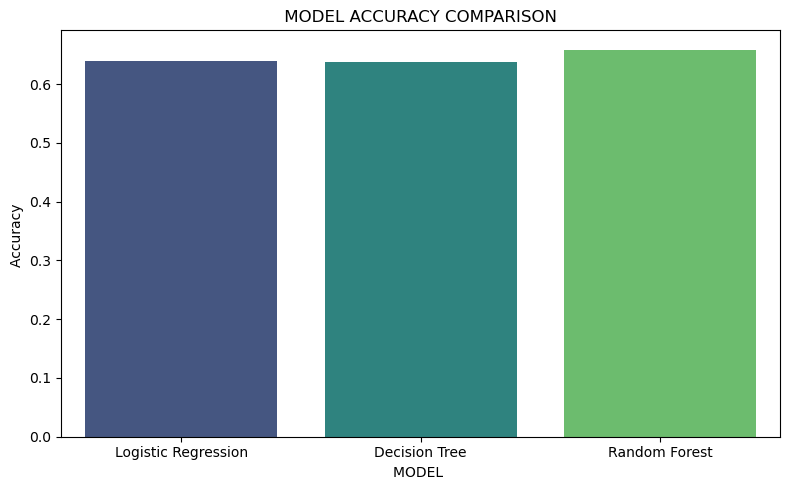

In [191]:
plt.figure(figsize = (8,5))
sns.barplot(x =  "MODEL " , y = "Accuracy " , data=results_df, palette = "viridis")
plt.title(' MODEL ACCURACY COMPARISON ')
plt.tight_layout()
plt.show()
            

In [194]:
from imblearn.over_sampling import SMOTE 
## Balancing with SMOTE to address class imbalance

In [197]:
x = df.drop("Reached.on.Time_Y.N", axis = 1)
y = df["Reached.on.Time_Y.N"] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

### SMOTE

In [200]:
smote = SMOTE(random_state = 42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [202]:
print(y_train_smote.value_counts())

Reached.on.Time_Y.N
0    5258
1    5258
Name: count, dtype: int64


In [204]:
# RANDOM FOREST
rf = RandomForestClassifier(random_state = 42)
rf.fit(x_train_smote, y_train_smote)

# Predict on the test data ( not Oversampled )

y_pred_rf = rf.predict(x_test)

# Evaluate 

print("Accuracy : ", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n" , confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy :  0.6727272727272727
Confusion Matrix:
 [[689 206]
 [514 791]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.77      0.66       895
           1       0.79      0.61      0.69      1305

    accuracy                           0.67      2200
   macro avg       0.68      0.69      0.67      2200
weighted avg       0.70      0.67      0.67      2200



In [205]:
# decision tree
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(x_train_smote, y_train_smote)
y_pred_dt = dt.predict(x_test)


print(" DECISION TREE ")
print("Decision Tree Accuracy: ", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

 DECISION TREE 
Decision Tree Accuracy:  0.6540909090909091
Confusion Matrix:
 [[515 380]
 [381 924]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.58       895
           1       0.71      0.71      0.71      1305

    accuracy                           0.65      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.65      0.65      0.65      2200



In [206]:
lr = LogisticRegression()
lr.fit(x_train_smote, y_train_smote)
y_pred_lr = lr.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6509090909090909
Confusion Matrix:
 [[665 230]
 [538 767]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.74      0.63       895
           1       0.77      0.59      0.67      1305

    accuracy                           0.65      2200
   macro avg       0.66      0.67      0.65      2200
weighted avg       0.68      0.65      0.65      2200



In [207]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Define a function to collect metrics
def get_model_scores(y_test, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

results = []
results.append(get_model_scores(y_test, y_pred_dt, 'Decision Tree'))
results.append(get_model_scores(y_test, y_pred_lr, 'Logistic Regression'))
results.append(get_model_scores(y_test, y_pred_rf, 'Random Forest'))  

# Create a DataFrame for easy plotting
results_df = pd.DataFrame(results)

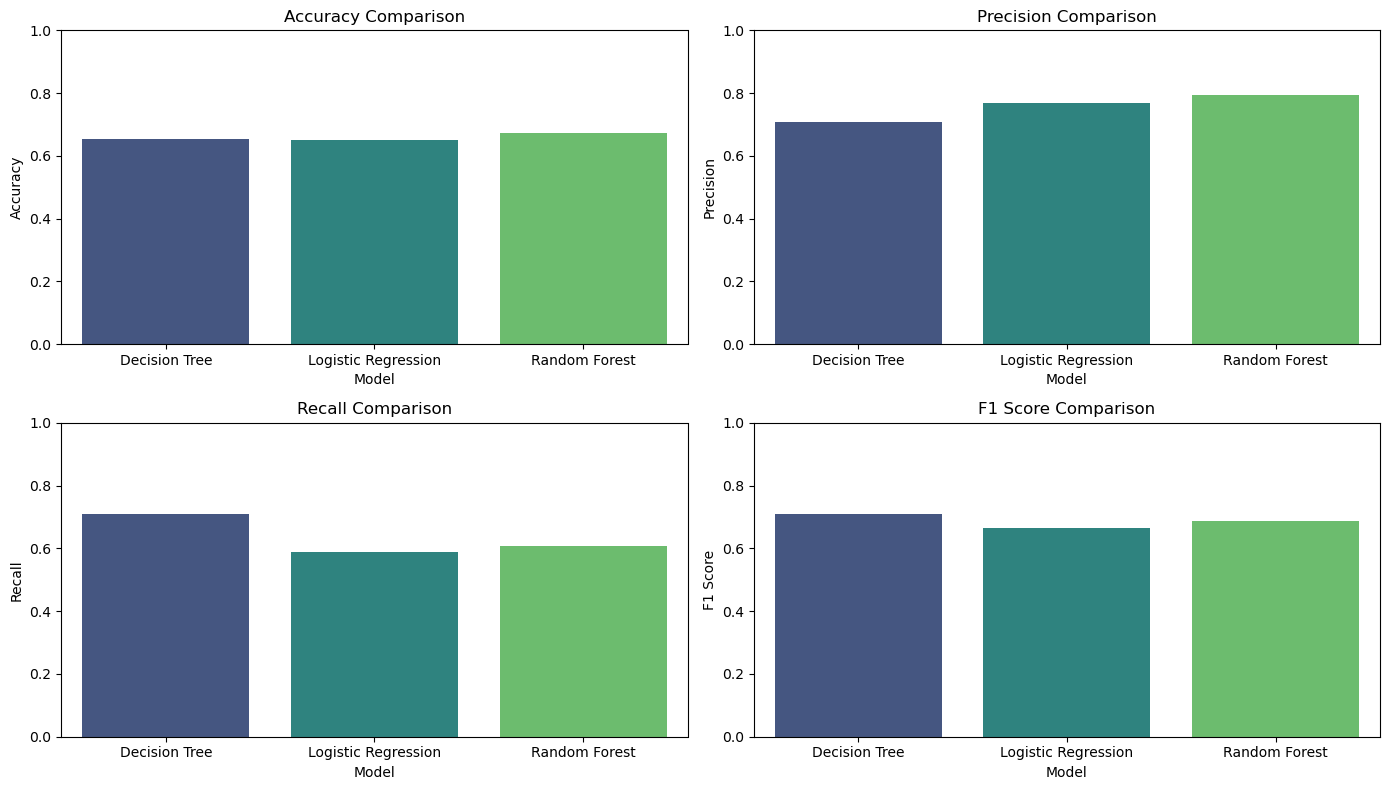

In [212]:
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
    plt.title(f'{metric} Comparison')
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

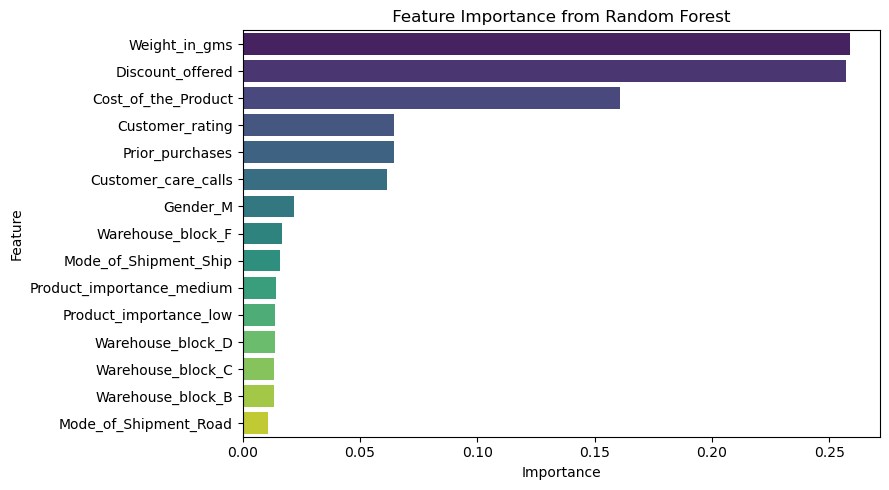

In [213]:
# Featutre importance analysis from random forest 
feature_importances = rf.feature_importances_
features = x_train.columns  

# creating dataframe for easy plotting
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feat_imp_df = feat_imp_df.sort_values(by= 'Importance' , ascending = False)

# plot

plt.figure(figsize =(9,5))
sns.barplot(x = 'Importance', y = 'Feature', data = feat_imp_df, palette = 'viridis')
plt.title(' Feature Importance from Random Forest ')
plt.tight_layout()
plt.show()


##  Feature Impact on Late Deliveries

###  Based on the Random Forest feature importance plot:
#### - **Weight_in_gms**: Heavier products often cause delays due to logistical constraints.
#### - **Discount_offered**: High discounts may lead to bulk orders → pressure on delivery.
#### - **Customer_rating**: May indicate quality of service → correlated with delivery satisfaction.
#### - **Prior_purchases & Customer_care_calls**: Indicates repeated customers and complaints → delay signals

In [218]:
rf.fit(x_train_smote, y_train_smote)

# Use probabilities from Random Forest
y_probs = rf.predict_proba(x_test)[:, 1] 
print(y_probs)

[0.99 0.24 0.65 ... 0.24 0.5  0.21]


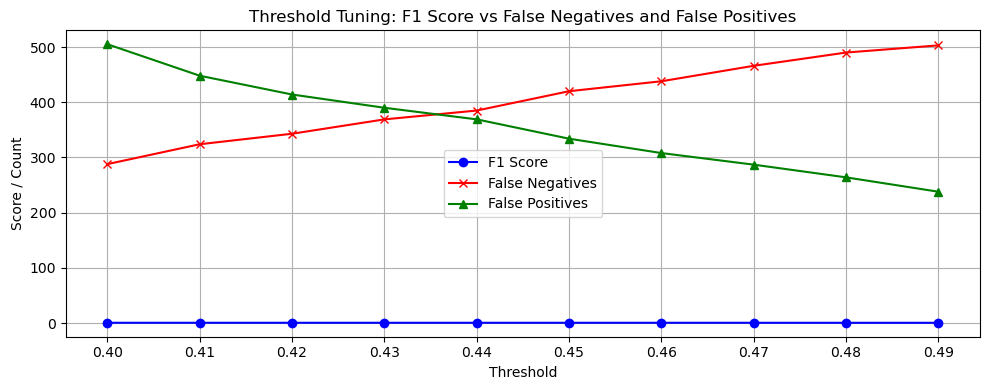

In [219]:
# Trying multiple thresholds
thresholds = np.arange(0.40, 0.50, 0.01)
f1_scores = []
false_negatives = []
false_positives = []

for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    false_negatives.append(fn)
    false_positives.append(fp)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, label='F1 Score', marker='o', color='blue')
plt.plot(thresholds, false_negatives, label='False Negatives', marker='x', color='red')
plt.plot(thresholds, false_positives, label='False Positives', marker='^', color='green')

plt.title("Threshold Tuning: F1 Score vs False Negatives and False Positives")
plt.xlabel("Threshold")
plt.ylabel("Score / Count")
plt.xticks(thresholds)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Confusion Matrix at Optimized Threshold:
[[481 414]
 [343 962]]


<Figure size 600x400 with 0 Axes>

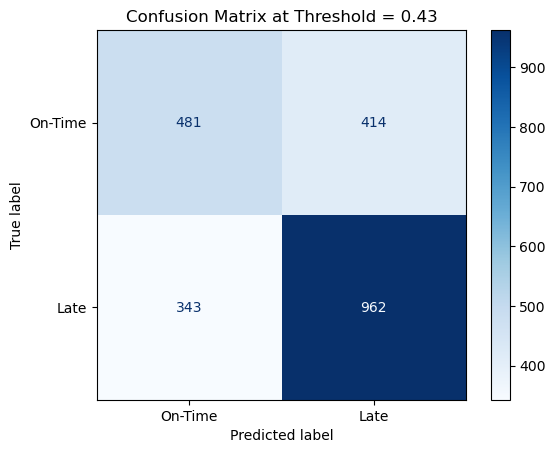


Classification Report at Optimized Threshold:
              precision    recall  f1-score   support

     On-Time       0.58      0.54      0.56       895
        Late       0.70      0.74      0.72      1305

    accuracy                           0.66      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.65      0.66      0.65      2200



In [220]:
from sklearn.metrics import ConfusionMatrixDisplay
optimal_threshold = 0.43
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

#  Print the Confusion Matrix
print("Confusion Matrix at Optimized Threshold:")
cm = confusion_matrix(y_test, y_pred_opt)
print(cm)

#  Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-Time", "Late"])
plt.figure(figsize=(6, 4))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix at Threshold = 0.43")
plt.grid(False)
plt.show()

#  Print the Classification Report
print("\nClassification Report at Optimized Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=["On-Time", "Late"])) 

In [222]:
# After comparing all models using accuracy, F1 Score, and confusion matrix, **Random Forest** was selected.
# It balances both **false negatives** and **false positives**, which is important for reducing false promises and false alerts.
# **Threshold was tuned** (0.43) to maximize F1 Score while controlling both types of errors.

In [226]:
df.to_csv("C:/Users/SRISHTI/Downloads/FInal_Ecommerce_data.csv", index=False)

